In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import cupy as cp
import igpu

## Read the imaging data

This synthetic data is the small example. This contains 3 neuronal sequences.

You can generate all the synthetic data used in the paper at `generate_synthetic_data.ipynb`.

In [2]:
x = igpu.open_csv_nonull("t3000/gen_n300_k3_l50_t3000_seed20.csv")

## Matrix decomposition

You can change `random_seed` to test the performance.

In [3]:
random_seed = 0 # Change!
model = igpu.solve(x.T, k=20, l=50, z_th=x.min(), random_seed=random_seed, corr_max=0.3, comp_rate=0.1)

## The number of detected sequences

This `K` should be 3.

In [4]:
K = model.k
K

3

## Data visualization

### The shape of detected sequences (not sorted)

Detected sequences are contained in matrix `W`.

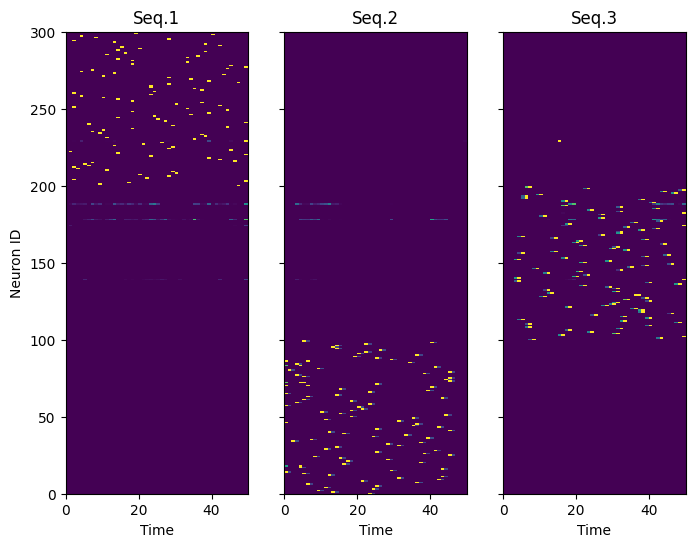

In [5]:
fix, axes = plt.subplots(1, K, sharey=True, figsize=(8, 6))
axes[0].set_ylabel("Neuron ID")
for ki in range(K):
    axes[ki].pcolor(model.W[:, ki, :].get(), vmax=0.001)
    axes[ki].set_xlabel("Time")
    axes[ki].set_title("Seq.{}".format(ki + 1))

### The shape and the intensity of detected sequences (sorted)

Neuron IDs were sorted based on `W`.

Then, the raw data, `W` and `H` were plotted based on the sorted Neuron ID.

In [6]:
dominant_id = model.W.max(axis=-1).argmax(axis=-1)
index = np.hstack([np.where(dominant_id == ki)[0][model.W[dominant_id == ki, ki, :].argmax(axis=-1).argsort()] for ki in range(K)])

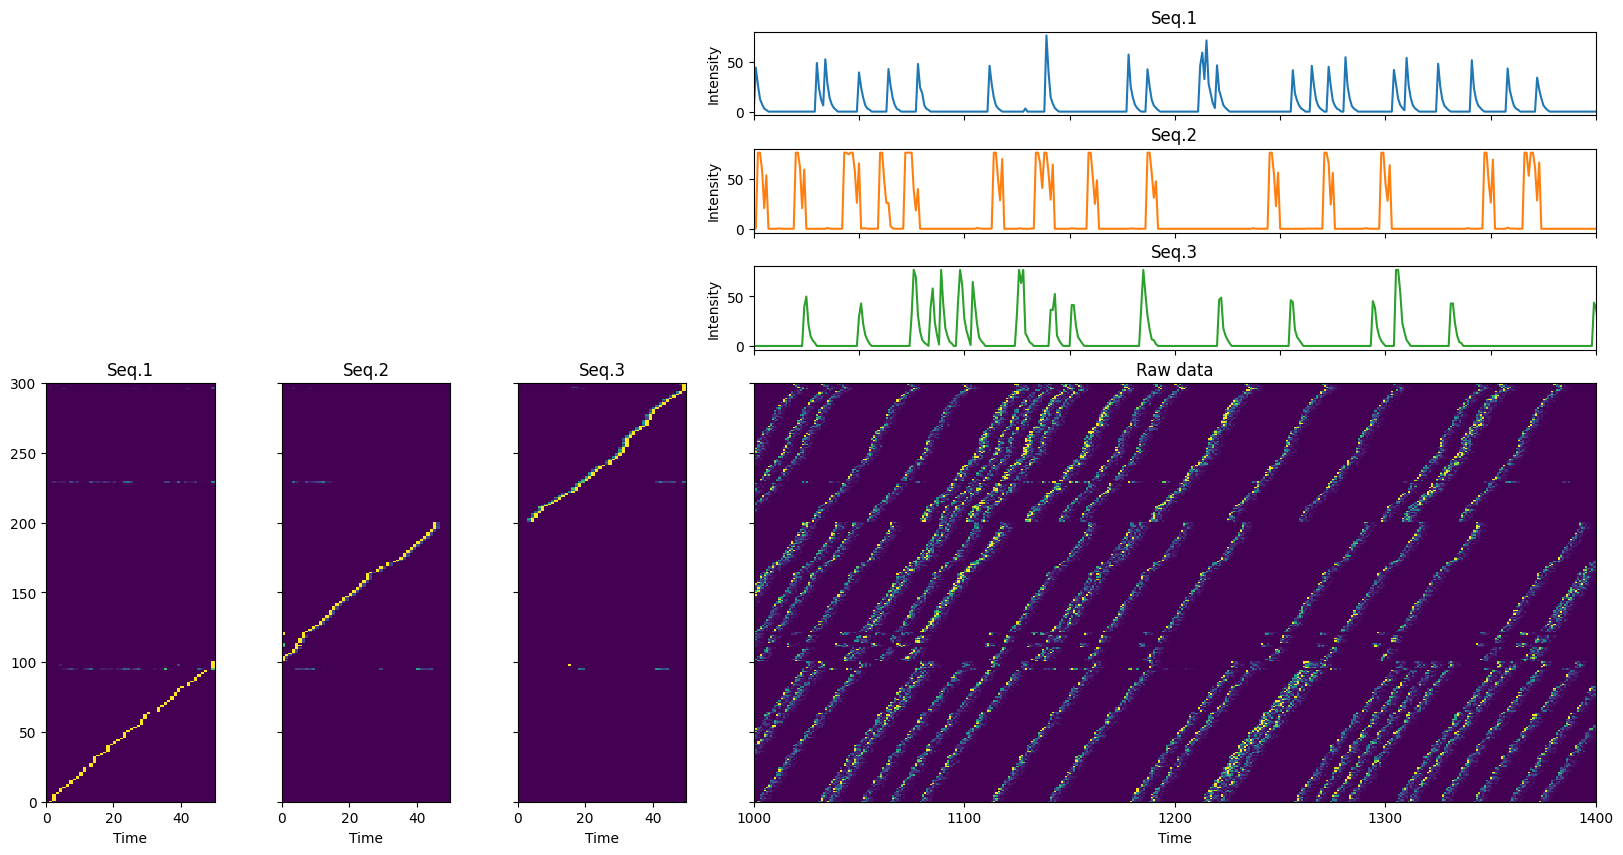

In [7]:
start, end = 1000, 1400
fix, axes = plt.subplots(K+1, K+1, width_ratios=[1]*K+[5], height_ratios=[1]*K+[5], figsize=(20, 10))
for ki in range(K):
    for kj in range(K):
        axes[ki, kj].axis("off")
axes[K, K].pcolor(x[start:end, index.get()].T, vmax=1)
axes[K, K].set_xticks(np.arange(0, end - start + 1, 100), np.arange(start, end+1, 100))
axes[K, K].set_xlabel("Time")
axes[K, K].set_title("Raw data")
axes[K, 0].set_xlabel("Neuron ID (sorted)")
for ki in range(K):
    axes[K, ki].pcolor(model.W[index, ki, :].get(), vmax=0.001)
    axes[K, ki].set_title("Seq." + str(ki+1))
    axes[K, ki].set_xlabel("Time")
    axes[K, ki+1].tick_params(labelleft=False)
    axes[ki, K].plot(model.H[ki, model.l-1:].get(), color="C" + str(ki))
    axes[ki, K].set_xlim(start, end)
    axes[ki, K].tick_params(labelbottom=False)
    axes[ki, K].set_title("Seq." + str(ki+1))
    axes[ki, K].set_ylabel("Intensity")